- This problem occurs when on updating the weights during gradient descent, there is almost no change in weights and thus almost no decrease in Loss. THis happens because back propagation deals with multiplication of multiple gradients terms, now when we multiply the terms which are already small in number, the result is even smaller, and thus when we subtract this gradient*lr to get the new weight, there is vanishingly small change in the weights.

### To recognize this problem, we can see that after every epoch, if the Loss decrease is stagnant or has stopped, this is generally the sign of VGP

In [1]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense

In [2]:
X,y = make_moons(n_samples = 1000 , noise = 0.05 , random_state= 42 )

In [4]:
X

array([[-0.02137124,  0.40618608],
       [ 0.97670045, -0.45832306],
       [ 0.90405882, -0.37651952],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]], shape=(1000, 2))

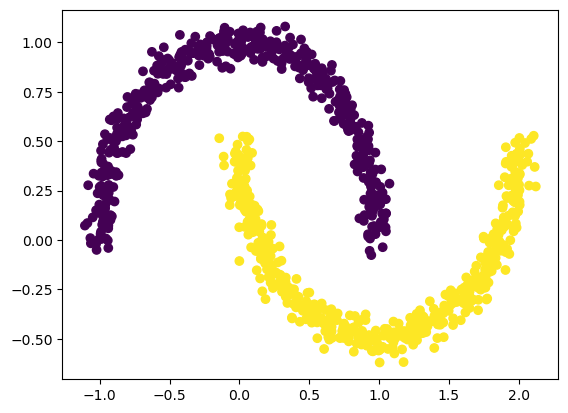

In [9]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0] , X[:,1] , c=y , cmap='viridis')
plt.show()

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [11]:
# building the Neural Network
model = Sequential()

model.add(Dense(10 , activation='sigmoid' , input_dim = 2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))


c:\Users\Pradhuman\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141 (4.46 KB)

 Trainable params: 1,141 (4.46 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(loss='binary_crossentropy' , optimizer='Adam', metrics = ['accuracy'])

In [15]:
old_weights = model.get_weights()[0]

In [ ]:
model.fit(X_train,y_train , epochs = 1) # trained for one time

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5000 - loss: 0.7130


In [24]:
# after training my weights must have changed
new_weights = model.get_weights()[0]

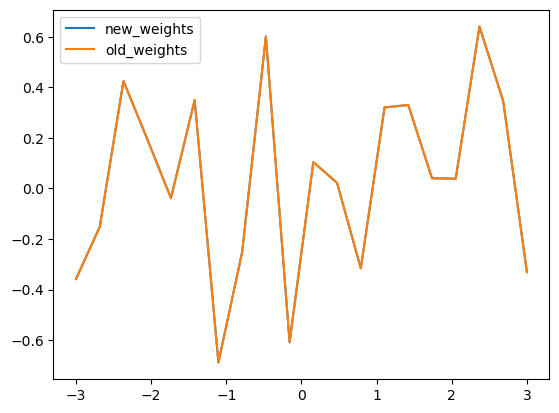

In [28]:
x_random = np.linspace(-3,3,20)
plt.plot(x_random , new_weights.flatten() , label='new_weights')
plt.plot(x_random , old_weights.flatten() , label='old_weights')
plt.legend()
plt.show()

- Can you interpret this? The new weights are almost identical with the old weights, this shows that there was close to none change after we did gradient descent for one loop

- Numerically we can see this using the values of gradients we got, and the percent change in the weights

In [32]:
lr = model.optimizer.get_config()['learning_rate'] # this gives the learning rate my optimizer is using
gradients = (old_weights - new_weights)/lr
percent_change = abs((new_weights - old_weights)/old_weights)*100

In [33]:
gradients

array([[-0.21597742, -0.6213933 , -0.02673268,  0.16801058,  0.00261515,
        -0.23475288,  0.00494719, -0.19067524,  0.5732775 ,  0.4355907 ],
       [ 0.12376159,  0.33999047,  0.01272559, -0.08913874, -0.0012219 ,
         0.1351051 , -0.00209734,  0.10263919, -0.35625693, -0.2733171 ]],
      dtype=float32)

- These are small values 

In [34]:
percent_change

array([[6.02743588e-02, 4.08074319e-01, 6.29713852e-03, 8.58588889e-02,
        6.84724143e-03, 6.71781078e-02, 7.18962052e-04, 7.55695254e-02,
        9.53544080e-02, 7.16197044e-02],
       [1.18849464e-01, 1.51904595e+00, 4.02520876e-03, 2.78493650e-02,
        3.70118069e-04, 3.34247231e-01, 5.44882845e-03, 1.60287004e-02,
        1.03287026e-01, 8.24957192e-02]], dtype=float32)

- already the change we see are very close to 0

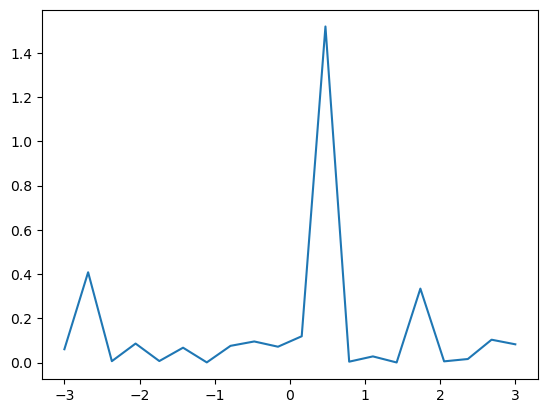

In [37]:
plt.plot(x_random , percent_change.flatten())

In [53]:
gradients

array([[-0.21597742, -0.6213933 , -0.02673268,  0.16801058,  0.00261515,
        -0.23475288,  0.00494719, -0.19067524,  0.5732775 ,  0.4355907 ],
       [ 0.12376159,  0.33999047,  0.01272559, -0.08913874, -0.0012219 ,
         0.1351051 , -0.00209734,  0.10263919, -0.35625693, -0.2733171 ]],
      dtype=float32)